In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [25]:
dataset_path = "PlantVillage"

print(os.listdir(dataset_path))

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


In [27]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [28]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 16516 images belonging to 15 classes.


In [29]:
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 4122 images belonging to 15 classes.


In [30]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(train_data.num_classes,activation='softmax'))

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=1
)

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


517/517 ━━━━━━━━━━━━━━━━━━━━ 86s 165ms/step - accuracy: 0.5650 - loss: 1.3423 - val_accuracy: 0.7603 - val_loss: 0.6993


In [33]:
from tensorflow.keras.preprocessing import image

img = image.load_img("test_leaf.jpg", target_size=(128,128))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

# Get predicted class index
pred_index = np.argmax(prediction)

# Convert to class label
class_labels = list(train_data.class_indices.keys())

print("Predicted Class:", class_labels[pred_index])
print("Confidence:", prediction[0][pred_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Predicted Class: Pepper__bell___healthy
Confidence: 0.9070795


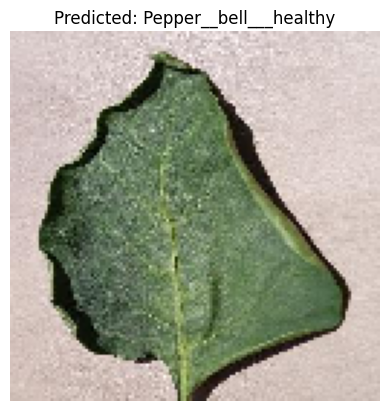

In [34]:
plt.imshow(img)
plt.title(f"Predicted: {class_labels[pred_index]}")
plt.axis('off')
plt.show()

In [35]:
from tensorflow.keras.preprocessing import image

img2 = image.load_img("test_leaf2.jpg", target_size=(128,128))
img_array = image.img_to_array(img2)

img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

# Get predicted class index
pred_index = np.argmax(prediction)

# Convert to class label
class_labels = list(train_data.class_indices.keys())

print("Predicted Class:", class_labels[pred_index])
print("Confidence:", prediction[0][pred_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Class: Tomato_Bacterial_spot
Confidence: 0.9324908


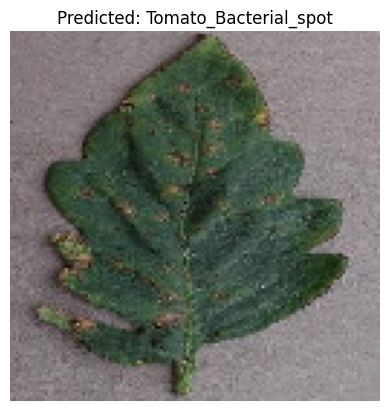

In [36]:
plt.imshow(img2)
plt.title(f"Predicted: {class_labels[pred_index]}")
plt.axis('off')
plt.show()